Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2572.84it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings [[-0.08502565 -0.02675338  0.0584699  ... -0.03350402 -0.00354917
   0.00807089]
 [ 0.00668677 -0.07361253  0.0508212  ...  0.09474272 -0.08166721
   0.0247052 ]
 [-0.14734212  0.06752743  0.00309739 ...  0.05638991  0.01679899
  -0.05100372]
 [-0.09042083 -0.03008345 -0.02802109 ...  0.0837101  -0.03209057
  -0.04519888]
 [-0.10790166 -0.01473675 -0.00562857 ...  0.09492887  0.01145197
  -0.00844645]
 [-0.02616267 -0.03613284 -0.01205508 ...  0.11142801 -0.08431756
   0.0070864 ]]
embeddings shape (6, 384)
[[ 0.46908736  0.39350832 -0.00726105  0.13914526  0.5560888   0.30106097]]
AI research papers


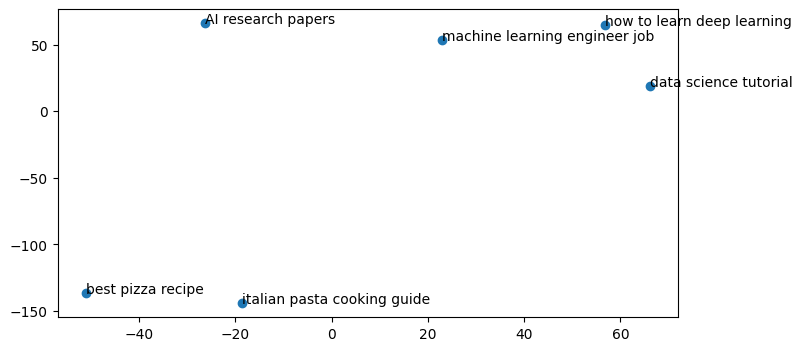

In [5]:

documents = [
"machine learning engineer job",
"how to learn deep learning",
"best pizza recipe",
"italian pasta cooking guide",
"AI research papers",
"data science tutorial"
]

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents)
print("embeddings" , embeddings)
print("embeddings shape" , embeddings.shape)

query = "how to start AI career"
query_embedding = model.encode([query])

from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(query_embedding, embeddings)

print(scores)

import numpy as np

best_match = np.argmax(scores)

print(documents[best_match])

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

reduced = TSNE(n_components=2 , perplexity=2, random_state=42).fit_transform(embeddings)
plt.figure(figsize=(8 , 4))
plt.scatter(reduced[:,0], reduced[:,1])

for i, text in enumerate(documents):
    plt.annotate(text, (reduced[i,0], reduced[i,1]))

plt.show()